# Readout Errors
To understand the readout error and to design an algorithm to mitigate it, the raw data should be extracted from the backend. Usually, quantum computing backends (including IBM) readout data are in binary system ("0" or "1"). However, under the hood, the quantum computer is actually bouncing a microwave pulse off the qubit and measuring its electrical signal. The raw signal readout voltages has an I (In-phase) and a Q (Quadrature) components that creates a coordinate on a 2D map, where the states of the qubit and its error is derived based on the I&Q data map after measuring them for several thousands shots.

The readout error is defined as:

$P_{readout-error}$ = P_read0_given1 + P_read1_given0


### Data Extraction
To extract the I&Q components (the raw readout voltages) from the IBM backend, the `StateTomography` class of the `qiskit_experiments` library was used. The following snippet shows the steps to extract IQ data for a single qubit after creating a basic circuit:

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit_experiments.library import StateTomography

# connecting to ibm
service = QiskitRuntimeService()
backend = service.backend("ibm_fez")

# creating the basic circuit
qc = QuantumCircuit(1)
qc.measure_all()

# reconstructing quantum state and measuring in Z, X, Y basis 
exp = StateTomography(qc)

# transpiler is the qiskit translator
exp.set_transpile_options(translation_method='translator',optimization_level=1 )
exp.set_run_options(meas_level=1, meas_return='single') # meas_level=1 --> asking for IQ voltage data

# run the experiment by sendig the job to ibm cloud --> most time consuming part
job = exp.run(backend,qubits=[nq],shots=150000) # --> shots = 15000 for this study to have enough data for ML algos; nq is the qubit ID
job.block_for_results()
iq = job.data()[0]['memory']
I,Q = iq[:, 0, 0], iq[:, 0, 1]

### IQ data for double-qubits

To include the crosstalk effects among neighboring qubits, and to include more comprehensive quantum states ($\ket{0}, \ket{1}$) multiple neighboring qubits should be selected among the backend qubits. As the computational power is limited the number of qubits are limited to two qubits. An educated guess is to select a qubit and find the neighbor with highest readout error and run the `StateTomography` for both of them. To use IQ data for Machine Learning algorithms, `nshot=15000`. The data are prepared in four states: $\ket{00}, \ket{01}, \ket{10}, \ket{11}$ where the indices are: $\ket{n1}\ket{n2}$

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
import os

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
props = backend.properties()
nq1 = 127
coupling_map = backend.coupling_map
connections = coupling_map.get_edges()
neighbors = coupling_map.neighbors(nq1)
rerrors = [np.round(props.readout_error(i),3).item() for i in list(neighbors)]
nq2 = [i for i in list(neighbors) if np.round(props.readout_error(i),3).item() == max(rerrors)][0]
print(f'2nd qubit index: {nq2}, readout-error={rerrors}, all neighbors:', neighbors)

def job_state(nq1,nq2,i,j):
    qc = QuantumCircuit(2)
    if i > 0: qc.x(0)
    if j > 0: qc.x(1)
    qc.measure_all()
    exp = StateTomography(qc)
    exp.set_transpile_options(translation_method='translator',optimization_level=1 )
    exp.set_run_options(meas_level=1, meas_return='single')
    job = exp.run(backend,qubits=[nq1,nq2],shots=15000)
    job.block_for_results()

    iq1, iq2 = job.data()[0]['memory'], job.data()[0]['memory']
    I1,Q1 = iq1[:, 0, 0], iq1[:, 0, 1]
    I2,Q2 = iq2[:, 1, 0], iq2[:, 1, 1]
    return I1,Q1, I2,Q2

# assuming nq2 = 128:
I1_00, Q1_00, I2_00, Q2_00 = job_state(127, 128, 0, 0) # both qubits in state |0>
I1_11, Q1_11, I2_11, Q2_11 = job_state(127, 128, 1, 1) # both qubits in state |1>
I1_01, Q1_01, I2_01, Q2_01 = job_state(127, 128, 0, 1) # 127: |0>, 128: |1>
I1_10, Q1_10, I2_10, Q2_10 = job_state(127, 128, 1, 0) # 127: |1>, 128: |0>

X00 = np.column_stack([I1_00, Q1_00, I2_00, Q2_00])  # shape (shots_00, 4)
X01 = np.column_stack([I1_01, Q1_01, I2_01, Q2_01])  # shape (shots_01, 4)
X10 = np.column_stack([I1_10, Q1_10, I2_10, Q2_10])  # shape (shots_10, 4)
X11 = np.column_stack([I1_11, Q1_11, I2_11, Q2_11])  # shape (shots_11, 4)

# Save data as npz file as this process will exhaust the ibm queue
np.savez(os.getcwd()+'/../files/datafiles/x.npz', X00=X00, X01=X01, X10=X10, X11=X11)


qiskit_runtime_service.__init__:WARNING:2026-05-18 11:54:18,284: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-18 11:54:18,285: Using instance: open-instance, plan: open


2nd qubit index: 126, readout-error=[0.151, 0.007, 0.035], all neighbors: NodeIndices[126, 137, 128]


### Visualize IQ Data
Plotting IQ data for individual qubits and various states shows how separable the IQ plots are for different states, and how the readout error could be mitigated by separating them. In addition, IQ plots for multiple qubits shows the crosstalk effect of neighboring qubits.

These scenarios are plotted followingly:

1. The effect of neighboring ground states on the qubit excited state: $\ket{00}$ and $\ket{01}$ for qubit=127 and $\ket{00}$ and $\ket{10}$ for qubit=128
2. The effect of neighboring excited states on the excited state: $\ket{11}$ and $\ket{01}$ for qubit=127 and $\ket{11}$ and $\ket{10}$ for qubit=128

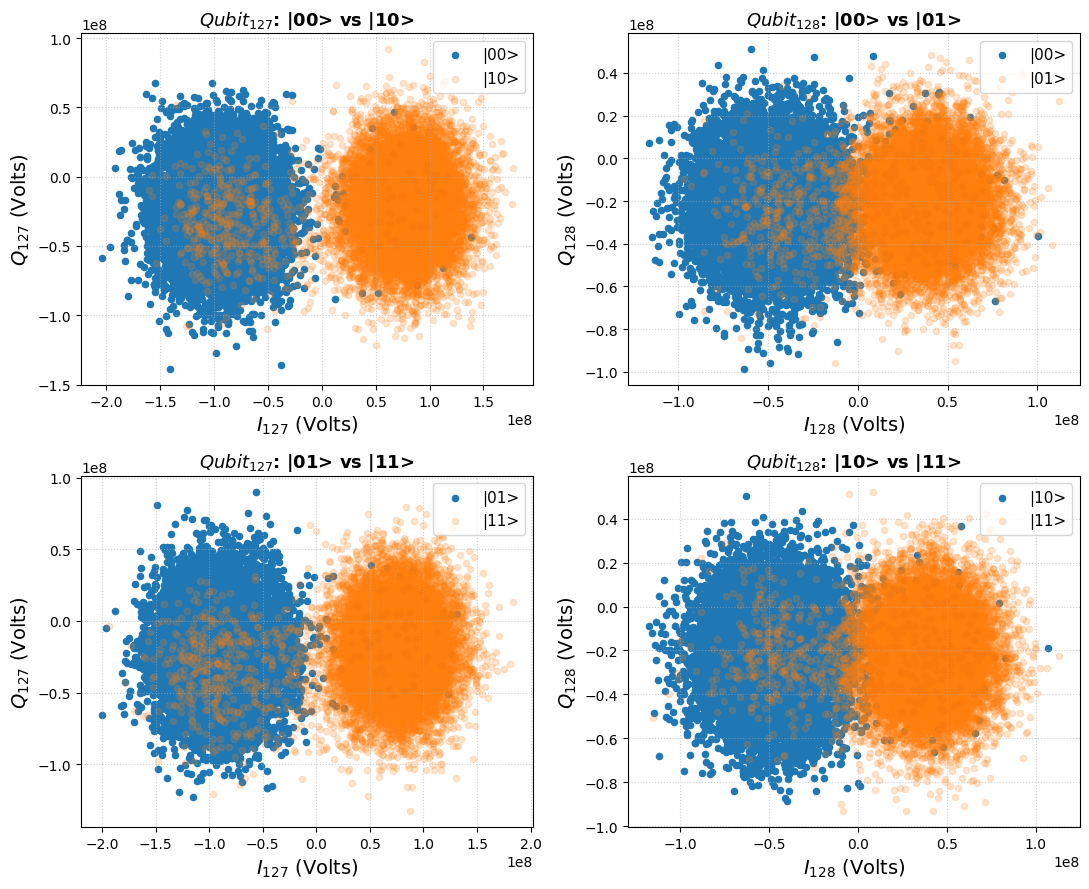

In [ ]:
import matplotlib.pyplot as plt

data = np.load(os.getcwd()+'/files/datafiles/x.npz')
X00, X11, X01, X10 = data['X00'], data['X11'], data['X01'], data['X10']

grid_config = [
    (0, 0, 127, 0, 1, X00, '|00>', X10, '|10>', 0.2), 
    (0, 1, 128, 2, 3, X00, '|00>', X01, '|01>', 0.2),
    (1, 0, 127, 0, 1, X01, '|01>', X11, '|11>', 0.2),
    (1, 1, 128, 2, 3, X10, '|10>', X11, '|11>', 0.2)
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for row, col, i, i_col, q_col, X_prim, lbl_prim, X_sec, lbl_sec, a_sec in grid_config:
    ax = axes[row, col]
    ax.scatter(X_prim[:, i_col], X_prim[:, q_col], s=20, alpha=1.0, label=lbl_prim)
    ax.scatter(X_sec[:, i_col], X_sec[:, q_col], s=20, alpha=a_sec, label=lbl_sec)
    ax.set_xlabel(fr"$I_{{{i}}}$ (Volts)", fontsize=14)
    ax.set_ylabel(fr"$Q_{{{i}}}$ (Volts)", fontsize=14)
    ax.set_title(fr'$Qubit_{{{i}}}$: {lbl_prim} vs {lbl_sec}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

From this plot it is shown that qubit 128 has a higher readout error. This could also be shown by:

In [52]:
# N.B.: the downloaded X arrays where not synched with the following errors!!!
q128_rerr = props.readout_error(128)
q127_rerr = props.readout_error(127)
print(f'readout error for qubit = 128:   {q128_rerr*100:.3f}%,   qubit = 127:  {q127_rerr*100:.3f} %')

readout error for qubit = 128:   3.503%,   qubit = 127:  8.142 %


### IQ Map Geometrical Parameters
To identify what are the tilting angle of the 2D distribution of IQ map and how well the distribution is circular, the two parameters below are used:

$$\theta = 0.5 \times arctan{\frac{\sigma_{IQ}}{\sigma_{II}-\sigma_{QQ}}}$$
$$\rho = \frac{\sigma_{IQ}}{\sqrt{\sigma_{II}\times\sigma_{QQ}}}$$

The amount the distribution is tilted w.r.t. the horizontal axis is assessed with $\theta$ (measured in degrees): low values small tilting and high values large tilting;

The amount the distribution is symmetric (or circular) in IQ plane is evaluated with $\rho$ values: small $\rho$ IQ mapping is circular, large $\rho$ IQ mapping is elliptical


In [ ]:
def compute_geom(data, state):
    cov = np.cov(data.T)
    theta = 0.5 * np.arctan2(2 * cov[0,1], cov[0,0] - cov[1,1])
    rho = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    print(f'  |{state}>  theta = {np.degrees(theta):.2f} degree,     rho = {rho:.2e} ')
    return theta, rho

state = {0 : '00', 1 : '01', 2 : '10', 3 : '11'}

for q in (127, 128):
    print(f'qubit: {q}')
    for n,x in enumerate([X00, X01, X10, X11]):
        compute_geom(x[:,:2], state[n]) if q == 127 else compute_geom(x[:,2:], state[n])

qubit: 127
  |00>  theta = -0.73 degree,     rho = -2.20e-03 
  |01>  theta = 5.33 degree,     rho = 1.46e-02 
  |10>  theta = 5.55 degree,     rho = 6.44e-02 
  |11>  theta = 6.58 degree,     rho = 7.96e-02 
qubit: 128
  |00>  theta = 2.74 degree,     rho = 1.19e-02 
  |01>  theta = 5.18 degree,     rho = 3.14e-02 
  |10>  theta = -0.06 degree,     rho = -2.66e-04 
  |11>  theta = 0.69 degree,     rho = 4.09e-03 


### Distance from IQ blob
Used Mahalanobis distance instead of Eucleadian distance to account for the IQ-plane diagonal variance. To see the effect of the Modified Minimum covariant the empirical covariance and the minimum covariance methods are used. For the purpose of demonstration MCD and original Mahalanobis distances are used on the entire datasets.

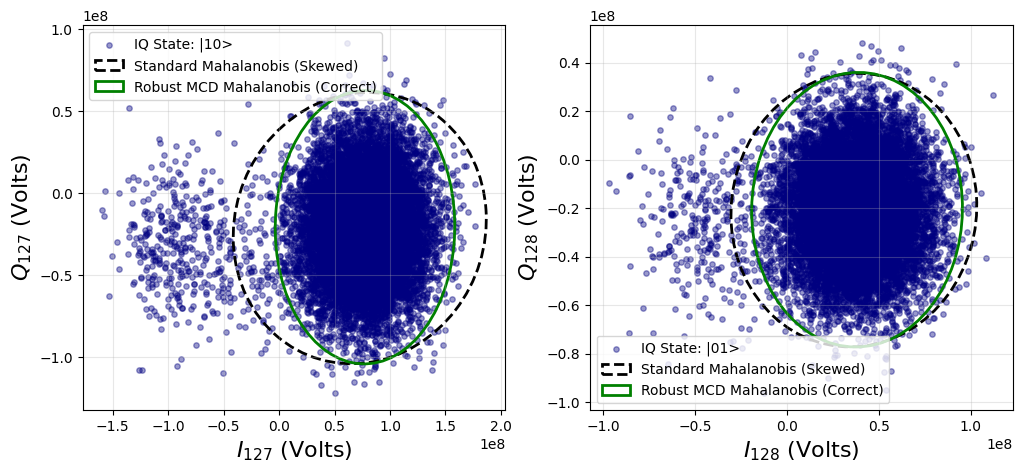

In [ ]:
from sklearn.covariance import MinCovDet, EmpiricalCovariance
from matplotlib.patches import Ellipse

def draw_ellipse(mcd, ax, color, label, linestyle='-'):
    """Draws a 3-sigma Mahalanobis contour."""
    cov = mcd.covariance_
    center = mcd.location_
        
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
        
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))        
    width, height = 2 * 3 * np.sqrt(vals)
        
    ell = Ellipse(xy=center, width=width, height=height, angle=theta,
                      edgecolor=color, facecolor='none', lw=2, 
                      linestyle=linestyle, label=label)
    ax.add_patch(ell)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i,nqu in enumerate([127, 128]):
    if nqu == 127:
        ax[i].scatter(X10[:,0], X10[:,1], color='navy', alpha=0.4, s=15, label=f'IQ State: |10>')
        standard_cov = EmpiricalCovariance().fit(X10[:,:2])
        robust_cov = MinCovDet().fit(X10[:,:2]) 
    else:
        ax[i].scatter(X01[:,2], X01[:,3], color='navy', alpha=0.4, s=15, label=f'IQ State: |01>')
        standard_cov = EmpiricalCovariance().fit(X01[:,2:])
        robust_cov = MinCovDet().fit(X01[:,2:])
    draw_ellipse(standard_cov, ax[i], 'black', 'Standard Mahalanobis (Skewed)', '--')
    draw_ellipse(robust_cov, ax[i], 'green', 'Robust MCD Mahalanobis (Correct)')
    ax[i].set_xlabel(fr"$I_{{{nqu}}}$ (Volts)", fontsize=16)
    ax[i].set_ylabel(fr"$Q_{{{nqu}}}$ (Volts)", fontsize=16)
    ax[i].legend()
    ax[i].grid(True, alpha=0.3)

plt.savefig(os.getcwd()+'/files/plots/maha_qu1-10_qu2-01.png')

### Quantum States IQ Separation
1. Mahalanobis distance: Useful to eliminate outliers;
2. Gaussian Mixture Models: Takes all the combinations of double-qubits' states as input;
3. SVC Models: State Vector Classification model 
4. LR Model: Benchmark to evaluate other models

Used 80% of data to train and 20% for test with the same random state for the purpose of valid comparison among runs

In [91]:
from sklearn.model_selection import train_test_split

X = np.vstack([X00, X01, X10, X11])

y = np.concatenate([
    np.zeros(len(X00)),
    np.ones(len(X01)),
    np.full(len(X10), 2),
    np.full(len(X11), 3)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

def train_mcd_discriminator_multi(X_list):
    params = []
    for X in X_list:
        mcd = MinCovDet().fit(X)
        mu = mcd.location_
        inv_cov = np.linalg.inv(mcd.covariance_)
        params.append((mu, inv_cov))    
    return params

def predict_mcd_multi(X_test, all_params):
    distances = []
    for mu, inv_cov in all_params:
        diff = X_test - mu
        dist = np.sqrt(np.sum(np.dot(diff, inv_cov) * diff, axis=1))
        distances.append(dist)
    distances = np.array(distances) 
    return np.argmin(distances, axis=0) 

XT = [X_train[y_train==i] for i in range(4)]
mcd_params = train_mcd_discriminator_multi(XT)
predictions = predict_mcd_multi(X_test, mcd_params)

accuracy = np.mean(predictions == y_test)
debug = False
print(f"MCD Multi-class Accuracy: {accuracy * 100:.2f}%")

state_map = {0: "|00>", 1: "|01>", 2: "|10>", 3: "|11>"}
mah_confmatrix = {}
for i in range(4):
    X_test_i = X_test[y_test == i]
    pred_01 = predict_mcd_multi(X_test_i, mcd_params)
    unique, counts = np.unique(pred_01, return_counts=True)
    results = dict(zip(unique, counts))
    if debug == True: print(f"Prediction Breakdown for True State: {state_map[i]}")
    per = []
    for label, count in results.items():
        p = (count / len(pred_01))
        per.append(np.round(p,3).item())
        if debug == True: print(f"  Predicted as {state_map[label]}: {count} times ({p*100:.2f}%)")
    mah_confmatrix[i] = per
    if debug == True: print('\n','--'*100)

MCD Multi-class Accuracy: 95.52%


In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC # --> SVC: classification class of SVM (State Vector Machine)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

state_labels = ["|00>", "|01>", "|10>", "|11>"]

# LR Model
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# GMM used MCD initial means and precision to exclude outliers
initial_means = np.array([p[0] for p in mcd_params])
initial_precisions = np.array([p[1] for p in mcd_params])
gmm = GaussianMixture(n_components=4, covariance_type='full', means_init=initial_means, random_state=42) # means_init forces the mapping!
gmm.fit(X_train)
y_pred_gmm = gmm.predict(X_test)
cm_gmm = confusion_matrix(y_test, y_pred_gmm)

# SVC Model
svc = SVC(kernel='rbf', gamma='scale')
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
cm_svc = confusion_matrix(y_test, y_pred_svc)

if debug == True:
    print("Logistic Regression CM:\n", cm_lr)
    print("\n SVM CM:\n", cm_svc)
    print("\n GMM CM:\n", cm_gmm)
    print("\n Mah CM:\n", np.array([mah_confmatrix[i] for i in mah_confmatrix.keys()]))
    print("\n", "*"*150, "\n")

def fidelity(cm):
    P_i_given_i = []
    for i in range(cm.shape[0]):
        Nii = cm[i,i]
        Nij = sum([cm[i,j] for j in range(cm.shape[1]) if j!= i])
        P_i_given_i.append(Nii/(Nii+ Nij))
    return P_i_given_i
    
F_lr = fidelity(cm_lr)
F_svc = fidelity(cm_svc)
F_gmm = fidelity(cm_gmm)
F_mah = [mah_confmatrix[i][i] for i in mah_confmatrix.keys()]


print(f"{'State':<10} | {'LR  Fidelity':<17} | {'SVC Fidelity':<13} | {'GMM Fidelity':<13} |  {'MAH Fidelity':<15}")
print("-" * 100)

for i in range(4):
    state_label = f"|{bin(i)[2:].zfill(2)}>"
    print(f"{state_label:<10} | "
          f"{F_lr[i]:>10.3f}        |  "
          f"{F_svc[i]:>10.3f}   |"
          f"{F_gmm[i]:>10.3f}     |"
          f"{F_mah[i]:>10.3f}"
          )

State      | LR  Fidelity      | SVC Fidelity  | GMM Fidelity  |  MAH Fidelity   
----------------------------------------------------------------------------------------------------
|00>       |      0.962        |       0.965   |     0.967     |     0.964
|01>       |      0.958        |       0.960   |     0.958     |     0.962
|10>       |      0.956        |       0.955   |     0.954     |     0.954
|11>       |      0.944        |       0.940   |     0.940     |     0.941


### Models Result:
The fidelity of these models are approximately less than 1% of each other, which opens a great opportunity for improvement using more sophisticated ML algorithms

In [104]:
for i in range (4):
    lr_vs_svc = (F_lr[i]-F_svc[i])/F_svc[i]
    svc_vs_gmm = (F_gmm[i]-F_svc[i])/F_gmm[i]
    gmm_vs_mah = (F_gmm[i]-F_mah[i])/F_mah[i]
    print(f'{lr_vs_svc*100:.3f}, {svc_vs_gmm*100:.3f}, {gmm_vs_mah*100:.3f}')

-0.278, 0.242, 0.362
-0.285, -0.250, -0.421
0.034, -0.136, 0.018
0.424, -0.035, -0.147
